<a href="https://colab.research.google.com/github/Scrubert1207/PSO-Honors-Thesis/blob/main/Traffic_Counting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
np.set_printoptions(legacy='1.25')
import matplotlib.pyplot as plt
from collections import Counter

In [3]:
# List contains bidirectional traffic count, index 0 = 1st interval,
vehlist = [6,5,7,7,5,4,4,8,4,6,4,4,6,4,7,6,11,7,6,3,3,14,8,1,3,10,6,2,7,11,9,4,9,11,7,8,4,6,8,12,10,5,15,7,8,8,7,10,7,6,6,5,8,13,5,3,4,5,6,2]
print("list contains counts for", len(vehlist), 'intervals.')

list contains counts for 60 intervals.


In [4]:
three = []
for i in range(20):
  l = 3*i
  three.append(vehlist[l] + vehlist[l+1] + vehlist[l+2])

In [4]:
# Counts empirical frequency of various vehicle counts across all intervals, sorting to obtain array format with elements [vehicle count, empirical frequency]
Emp_Count = sorted(Counter(vehlist).items())
print(Emp_Count)

[(1, 1), (2, 2), (3, 4), (4, 9), (5, 6), (6, 10), (7, 9), (8, 7), (9, 2), (10, 3), (11, 3), (12, 1), (13, 1), (14, 1), (15, 1)]


In [6]:
# 3 count
three_counted = sorted(Counter(three).items())
print(three_counted)

[(12, 2), (13, 1), (14, 1), (16, 2), (17, 1), (18, 2), (19, 2), (20, 1), (22, 1), (23, 1), (24, 1), (25, 1), (26, 2), (27, 1), (30, 1)]


In [5]:
#example
vehicle_count = 6
print("There were", Emp_Count[vehicle_count - 1][1], "intervals with", vehicle_count, "vehicles.")

There were 10 intervals with 6 vehicles.


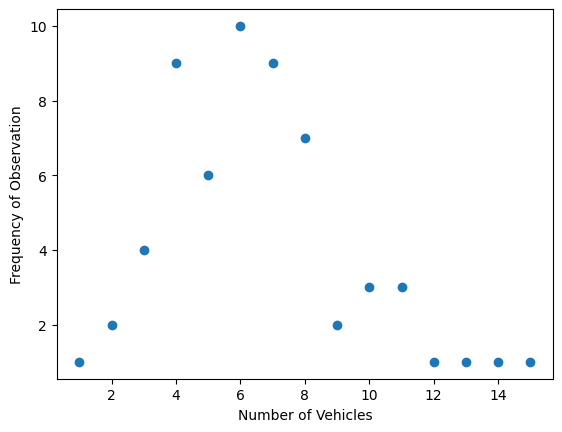

In [5]:
# Exploratory plots
transformed_counts = np.array(Emp_Count).T
plt.scatter(transformed_counts[0], transformed_counts[1])
plt.xlabel('Number of Vehicles')
plt.ylabel('Frequency of Observation')
plt.show()

Scatterplot above is essentially a histogram with 15 bins.

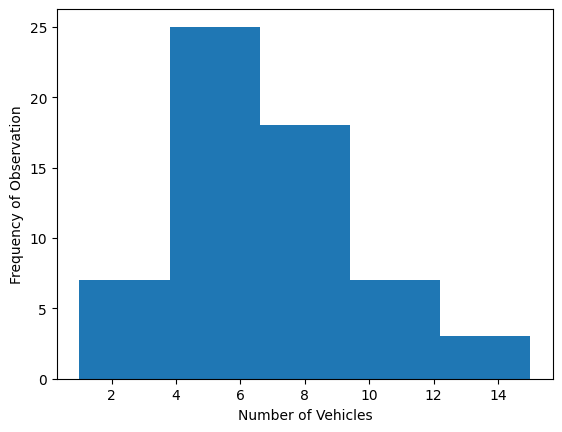

In [6]:
# Histogram
plt.hist(vehlist, bins = 5)
plt.xlabel('Number of Vehicles')
plt.ylabel('Frequency of Observation')
plt.show()

Next, we calculate the mean, or expected number of vehicles, using: $$\bar{n}=\frac{\sum_{i=1}^m n_i}{m}$$ Here, our $m = 60 =$ the number of counting intervals, and $n_i =$ number of observed vehicles during that interval.

In [6]:
mean = sum(vehlist)/len(vehlist)
print("The mean is =",mean)

The mean is = 6.616666666666666


In [7]:
#3
mean = sum(three)/len(three)
print("The mean is =",mean)

The mean is = 19.85


To get our variance, we use this equation: $$\mu_2 = \sigma^2 = \frac{\sum_{i=1}^m(n_i-\bar{n})^2}{m-1}$$

The standard deviation then naturally follows: $$\sigma = \sqrt{\sigma^2}$$

In [7]:
#variance len(list) - 1 for Bessel's correction
var = np.sum((np.array(vehlist) - mean)**2)/(len(vehlist)-1)
print("The variance is =",var)
sd = np.sqrt(var)
print("The standard deviation is =",sd)

The variance is = 8.816666666666666
The standard deviation is = 2.969287232092353


In [9]:
#variance & sd for 3
var = np.sum((np.array(three) - mean)**2)/(len(three)-1)
print("The variance is =",var)
sd = np.sqrt(var)
print("The standard deviation is =",sd)

The variance is = 28.344736842105267
The standard deviation is = 5.323977539594365


In [8]:
#variance-to-mean ratio
var_mean_ratio = var/mean
print("The variance-to-mean ratio is =",var_mean_ratio)

The variance-to-mean ratio is = 1.3324937027707808


For skewness, we look at: $$\mu_3 = \frac{\sum_{i=1}^m(n_i-\bar{n})^3}{m-1}$$

In [9]:
#skewness
skew = np.sum((np.array(vehlist) - mean)**3)/(len(vehlist)-1)
print("The skewness is =",skew)

The skewness is = 18.145602636534843


In [11]:
#skewness 3
skew = np.sum((np.array(three) - mean)**3)/(len(three)-1)
print("The skewness is =",skew)

The skewness is = 25.548157894736704


The hypothesis states that vehicle traffic at a point, if uninfluenced by some external surge or lull event, should follow a Poisson distribution $$P(n) = \frac{\lambda ^n \exp(-\lambda)}{n!}$$ Where $P(n)$ is the probability of $n$ vehicles during some interval, and $\lambda$ is our distribution parameter. If our data followed the Poisson distribution exactly, then mean $\bar{n}$ would exactly equal variance $\mu_2$. Our variance is higher in this case, indicating a more spreadout dataset than what Poisson expects. We choose $\lambda = \bar{n}$.


In [10]:
def Poisson(lam, freq, n):
  return lam**n * np.exp(-lam) / np.prod(np.arange(1, n + 1))

In [11]:
Emp_Count

[(1, 1),
 (2, 2),
 (3, 4),
 (4, 9),
 (5, 6),
 (6, 10),
 (7, 9),
 (8, 7),
 (9, 2),
 (10, 3),
 (11, 3),
 (12, 1),
 (13, 1),
 (14, 1),
 (15, 1)]

In [12]:
def Poisson(lam, freq, n):
  return lam**n * np.exp(-lam) / np.prod(np.arange(1, n + 1))

Poisson_List = []

# Manually adding 0-count Poisson prob because we did not encounter 0 in data
Poisson_List.append(Poisson(mean, 0, 0))

# Adding probabilities for n=1 through n=15
for entry in Emp_Count:
  Poisson_List.append(Poisson(mean, entry[1], entry[0]))

# Manually adding 16+ count Poisson prob
Poisson_List.append(1-sum(Poisson_List))

In [13]:
#Check that probability sums to 1, and display Poisson distribution values
print("Sum of PDF =", sum(Poisson_List))
print(np.round(Poisson_List, 5))

Sum of PDF = 1.0
[0.00134 0.00885 0.02929 0.06459 0.10685 0.14139 0.15593 0.14739 0.1219
 0.08962 0.0593  0.03567 0.01967 0.01001 0.00473 0.00209 0.00139]


The $i$th entry of our Poisson probabilities gives the probability for $i-1$ counts to be observed during each interval, e.g. the first entry gives the probability for no vehicles to be observed.

Thus, our theoretical frequency over 60 intervals is given by $$t = N\cdot P(n) = 60\cdot P(n)$$

In [14]:
Theoretical_Freq = 60*np.array(Poisson_List)
print(np.round(Theoretical_Freq, 5))

[0.08027 0.53114 1.75719 3.87557 6.41084 8.48368 9.35562 8.84329 7.31413
 5.37724 3.55794 2.14016 1.18006 0.60062 0.28386 0.12522 0.08316]


Theoretical Frequency := $t_i = N\cdot P(n_i)$ should be at least 5 for some grouped vehicle counts in order to ensure that the Chi-Squared test performed in the next step can feasibly approximate our distribution, since our data is discrete, while the $\chi ^2$ distribution is continuous.

If Chi-Squared (measure of discrepancy between 2 distributions) is too big at the end, i.e. > 9.236 for 0.10 sig, provides evidence that distribution is not poisson. Degree of freedom (in this case 5) is all bins of calculation / outcome - 1 (for input variable interval). Significance level of 0.05 indicates for 5% of times distribution will not follow empirical.

In [15]:
# Prepending and Appending to work with following bucketing
Theoretical_Freq = 60*np.array(Poisson_List)
Emp_Count_Augmented = [(0,0)] + Emp_Count + [(16,0)]
print(Emp_Count_Augmented)

[(0, 0), (1, 1), (2, 2), (3, 4), (4, 9), (5, 6), (6, 10), (7, 9), (8, 7), (9, 2), (10, 3), (11, 3), (12, 1), (13, 1), (14, 1), (15, 1), (16, 0)]


In [17]:
# Group theoretical frequencies into buckets such that total frequency in each bucket is at least 5
# Also aggregate associated empirical frequencies for the counts that are grouped, and find cutoffs for which get grouped
Pooled_Th_Freq = []
Pooled_Emp_Freq = []
bucket_t = 0
bucket_e = 0
counter = 0
cutoffs = []
while counter < 17:
  while bucket_t < 5:
    if counter == 16:
      # Once we get to the last theoretical frequency, just add it and everything left in the bucket to the last, so that our last bucket isn't < 5
      bucket_t += Theoretical_Freq[counter]
      bucket_e += Emp_Count_Augmented[counter][1]
      break
    else:
      bucket_t += Theoretical_Freq[counter]
      bucket_e += Emp_Count_Augmented[counter][1]
      counter += 1
  # Dumping bucket into pooled list once it fills up above 5, and clearing bucket

  if counter == 16:
    print('Topping up last bucket with:', bucket_t)
    Pooled_Th_Freq[-1] += bucket_t
    Pooled_Emp_Freq[-1] += bucket_e
    counter += 1
    cutoffs[-1] = 16
  else:
    print('Dumping bucket with pooled frequencies:', bucket_t)
    Pooled_Th_Freq.append(bucket_t)
    Pooled_Emp_Freq.append(bucket_e)
    bucket_t = 0
    bucket_e = 0
    cutoffs.append(counter-1)

Dumping bucket with pooled frequencies: 6.244172673444879
Dumping bucket with pooled frequencies: 6.4108440483129865
Dumping bucket with pooled frequencies: 8.483683623934185
Dumping bucket with pooled frequencies: 9.355617774171865
Dumping bucket with pooled frequencies: 8.843286324633883
Dumping bucket with pooled frequencies: 7.314134730999273
Dumping bucket with pooled frequencies: 5.377243496679094
Dumping bucket with pooled frequencies: 5.698099270878666
Topping up last bucket with: 2.2729180569451746


In [18]:
print("Pooled Theoretical Frequencies:",np.round(Pooled_Th_Freq, 5))
print("Pooled Empirical Frequencies:", Pooled_Emp_Freq)
print("Pooled Frequencies Cutoffs:", cutoffs)

Pooled Theoretical Frequencies: [6.24417 6.41084 8.48368 9.35562 8.84329 7.31413 5.37724 7.97102]
Pooled Empirical Frequencies: [7, 9, 6, 10, 9, 7, 2, 10]
Pooled Frequencies Cutoffs: [3, 4, 5, 6, 7, 8, 9, 16]


In [ ]:
cutoffs

[3, 4, 5, 6, 7, 8, 9, 16]

To obtain the $\chi ^2$ values for our data, use: $$\chi_1^2 = \frac{(t-e)^2}{t}$$

In [ ]:
def chi_sqr(th, emp):
  return (th - emp)**2 / th

In [ ]:
# Calculating Chi-Squared values for our buckets
Chi_Squared = chi_sqr(np.array(Pooled_Th_Freq), np.array(Pooled_Emp_Freq))
print("Chi-Squared Values:", np.round(Chi_Squared, 5))
print("Sum of Chi-Squared:", np.round(sum(Chi_Squared), 5))

Chi-Squared Values: [0.09149 1.04569 0.72712 0.04438 0.00278 0.01349 2.12112 0.51647]
Sum of Chi-Squared: 4.56254


Since we have 8 buckets of pooled frequencies, and 2 input parameters (counts and the Poisson $\lambda$ which we assumed from the mean), our total degrees of freedom is 8 - 2 = 6. The critical value for a significance level of 0.05 for 6 degrees of freedom is 12.592. Since our $\chi^2$ sum of 4.563 is below this, we reject the null hypothesis that our data isn't Poisson. However, this does not prove that it is; instead, it merely suggests that the null, stating our data isn't Poisson, can be rejected.

drive  sample_data


In [29]:
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/Traffic_Counting.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/Traffic_Counting.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 362300 bytes to /content/drive/MyDrive/Colab Notebooks/Traffic_Counting.html
